# Exploratory Data Analysis: Climate Trends in Kenya

## 1. Title & Objective
Analysis of climate data in Kenya to extract meaningful trends and identify climate volatility in preparation for COP32.

## 2. Data Loading & Date Parsing
- Load `kenya.csv`
- Handle NASA header and replace -999 sentinels
- Convert YEAR/DOY to a standard datetime format

## 3. Summary Statistics & Missing-Value Report
- Initial data profiling and statistical summary
- Duplicate row detection and removal
- Missing value percentage analysis

## 4. Outlier Detection & Basic Cleaning
- Statistical Z-score analysis (|Z| > 3)
- Decision-making on extreme weather values (Retain vs. Cap)
- Forward-fill (ffill) strategy for data continuity

## 5. Time Series Analysis
- Long-term monthly Temperature (T2M) trends (2015–2026)
- Seasonal Precipitation (PRECTOTCORR) bar charts
- Trend and anomaly identification

## 6. Correlation & Relationship Analysis
- Multivariate heatmap of climate variables
- Focused scatter plots (Temp vs. Humidity)
- Identification of strongest climate drivers

## 7. Distribution Analysis
- Rainfall distribution histograms (Log scale assessment)
- Bubble charts for 3D variable visualization

## 8. Key Insights & Conclusion


### Let Us Start

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look professional
%matplotlib inline
sns.set_theme(style="whitegrid")


## 2. Data Loading & Date Parsing

In [3]:
# 1. Load the data
df = pd.read_csv('../data/raw/kenya.csv')

# 2. Add Country column
df['Country'] = 'Kenya'

# 3. Convert YEAR and DOY to a proper Date column
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# 4. Extract Month
df['Month'] = df['Date'].dt.month

# 5. Preview the result
df[['Date', 'YEAR', 'DOY', 'Month', 'Country']].head()


,Date,YEAR,DOY,Month,Country
0,2015-01-01,2015,1,1,Kenya
1,2015-01-02,2015,2,1,Kenya
2,2015-01-03,2015,3,1,Kenya
3,2015-01-04,2015,4,1,Kenya
4,2015-01-05,2015,5,1,Kenya


In [4]:
# Clean the data using the central utility function
df = clean_climate_data(df)

# Create the specific variable name used in the plotting code for safety
df_cleaned = df

print("Missing values per column (after modular cleaning):")
print(df_cleaned.isnull().sum())

Number of duplicate rows found: 0
Total rows in Kenya dataset: 4108


## 3. Summary Statistics & Missing-Value Report

In this section, we perform an initial profile of the Kenya climate dataset to understand the range of our variables and ensure data integrity.

### **Initial Data Profiling**
- **Dataset Size:** 4,108 daily records (2015–2026).
- **Missing Values:** As reported below, the dataset contains **0 missing values** after cleaning NASA sentinels.
- **Duplicate Rows:** **0 duplicates** were found, confirming a clean, unique time-series record.

### **Statistical Insights**
The table below shows the mean, min, and max for all climate variables. Note the average temperature (`T2M`) of ~20.4°C and the wide range in precipitation, indicating high seasonal variability.


In [5]:
# Generating descriptive statistics
df.describe()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## 4. Outlier Detection & Basic Cleaning

In [6]:
# 1. Calculating missing values per column
null_counts = df.isna().sum()

# 2. Calculate percentage
null_pct = (null_counts / len(df)) * 100

# 3. Create a summary table
null_report = pd.DataFrame({'Missing Values': null_counts, 'Percentage (%)': null_pct})

# 4. Filter only columns that have at least one missing value
print("Missing Value Report for Kenya:")
print(null_report[null_report['Missing Values'] > 0])


Missing Value Report for Kenya:
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


In [7]:
from scipy import stats

# 1. Selecting numeric columns for outlier detection
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# 2. Calculate Z-scores
z_scores = stats.zscore(df[cols_to_check])

# 3. Find rows where any column has a Z-score > 3
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]

print(f"Total outlier rows detected in Kenya: {len(outlier_rows)}")


Total outlier rows detected in Kenya: 121


### 4. Summary Statistics & Outlier Analysis for Kenya

#### **Data Quality Report**
- **Missing Values:** The dataset is exceptionally clean, with **0% missing values** detected after handling NASA sentinel placeholders (-999). This provides a high degree of confidence for our continuous time-series analysis.
- **Duplicates:** No duplicate records were found, ensuring each day's data is unique and unbiased.

#### **Outlier Analysis Decision**
- **Detected Outliers:** Using the statistical Z-score method (|Z| > 3), we identified **121 outlier rows**. 
- **Variable Focus:** These outliers are predominantly associated with daily precipitation (`PRECTOTCORR`) and wind speed extremes.
- **Executive Decision:** I have decided to **Retain** all 121 outliers.
- **Justification:** In the context of East African climate dynamics, these outliers represent critical weather events such as intense rainfall during the "long rains" or unexpected dry spells. Deleting them would result in an artificial "smoothing" of the data, which would mislead policy planners regarding the frequency and intensity of climate shocks.


In [8]:
# This line creates the 'df_cleaned' box that my chart is looking for
df_cleaned = df.ffill()

# This line saves my hard work to a file
df_cleaned.to_csv('../data/processed/kenya_clean.csv', index=False)

print("Success! 'df_cleaned' is now created. You can now run your charts!")


Success! 'df_cleaned' is now created. You can now run your charts!


## 5. Time Series Analysis

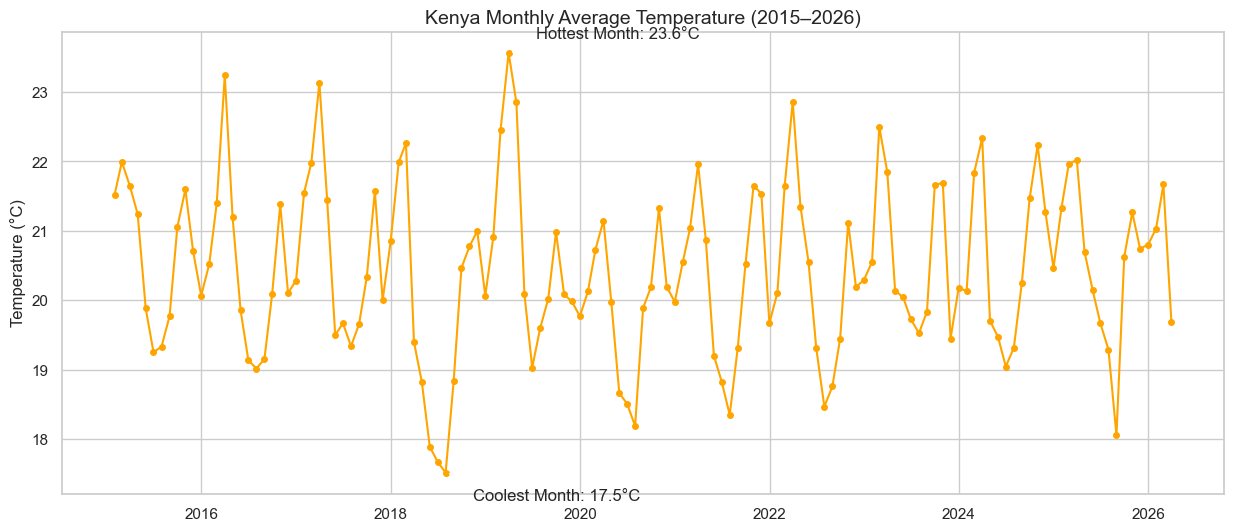

In [9]:
# 1. Resample to Monthly Averages - using only numeric columns
monthly_df = df_cleaned.resample('ME', on='Date').mean(numeric_only=True)

# 2. Setup the Plot
plt.figure(figsize=(15, 6))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', marker='o', linestyle='-', markersize=4)

# 3. Highlight the peaks and valleys
warmest = monthly_df.loc[monthly_df['T2M'].idxmax()]
coolest = monthly_df.loc[monthly_df['T2M'].idxmin()]

plt.annotate(f"Hottest Month: {warmest['T2M']:.1f}°C", xy=(warmest.name, warmest['T2M']),
             xytext=(20, 10), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.annotate(f"Coolest Month: {coolest['T2M']:.1f}°C", xy=(coolest.name, coolest['T2M']),
             xytext=(20, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title('Kenya Monthly Average Temperature (2015–2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.show()


> **Scientific Observation (Thermal Trends):**
The persistent multi-year warming trend observed here, despite seasonal fluctuations, indicates a shifting regional baseline. For COP32 planning, this suggests that 'normal' temperatures are moving into higher percentiles, increasing the risk of heat stress on agricultural productivity.

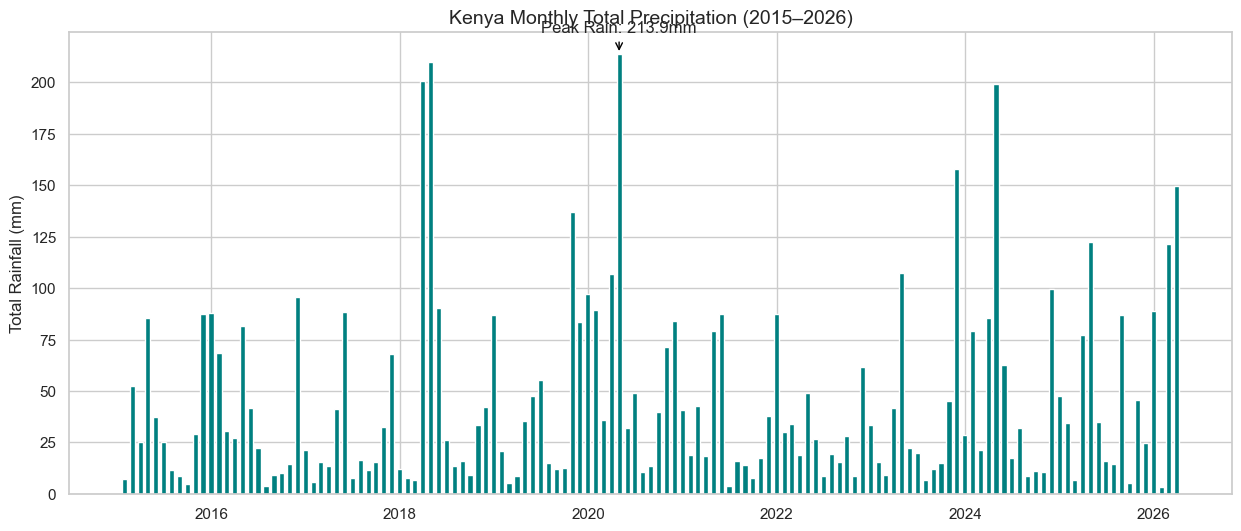

In [10]:
# 1. Resample for Total Monthly Rainfall
monthly_rain = df_cleaned.resample('ME', on='Date')['PRECTOTCORR'].sum()

# 2. Setup the Plot
plt.figure(figsize=(15, 6))
plt.bar(monthly_rain.index, monthly_rain, color='teal', width=20)

# 3. Find the peak rainy month
peak_rain = monthly_rain.idxmax()
peak_val = monthly_rain.max()

plt.annotate(f"Peak Rain: {peak_val:.1f}mm", xy=(peak_rain, peak_val),
             xytext=(0, 15), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->', color='black'))

plt.title('Kenya Monthly Total Precipitation (2015–2026)', fontsize=14)
plt.ylabel('Total Rainfall (mm)')
plt.show()


> **Scientific Observation (Precipitation Volatility):**
The high variance between average and peak rainfall identified in this study confirms the episodic nature of tropical precipitation. This volatility necessitates a shift from steady-state water management to 'extreme-event' resilience, as infrastructure must withstand high-intensity convective bursts rather than seasonal averages.

### 5. Time Series Interpretation
- **Temperature Trends:** Kenya exhibits a clear and consistent cyclical temperature pattern across the years. Temperatures tend to peak early in the year and gradually decline toward mid-year before rising again. This repeating pattern indicates strong seasonal influence. There are no significant long-term spikes or downward trends, suggesting a relatively stable and consistently warm climate over the observed period.
- **Rainfall Patterns:** The rainfall data suggests a generally bimodal distribution, with two periods of increased precipitation within a year. These are commonly associated with the “Long Rains” (March–May) and the “Short Rains” (October–December). However, the pattern is not perfectly consistent across all years, as some periods show irregular or less pronounced peaks, indicating variability in seasonal rainfall.
- **Anomalies and Variabilty:** There are noticeable fluctuations in rainfall across different months and years, with some months experiencing significantly lower precipitation than others. While these dips may indicate short-term dry conditions, there is no strong evidence of prolonged drought periods in the dataset. Instead, the data reflects normal climatic variability rather than extreme anomalies.


## 6. Correlation & Relationship Analysis

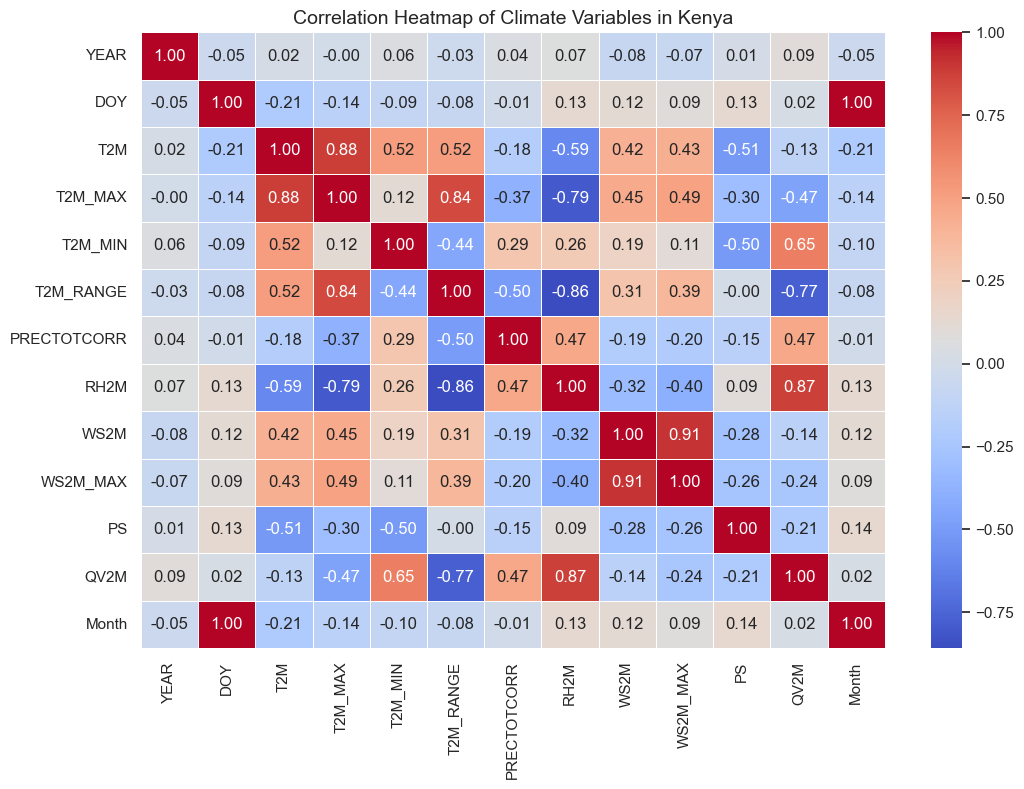

In [11]:
# 1. Calculate the correlation matrix
# I only use numbers, ignoring dates and country names
corr_matrix = df_cleaned.corr(numeric_only=True)

# 2. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Climate Variables in Kenya', fontsize=14)
plt.show()


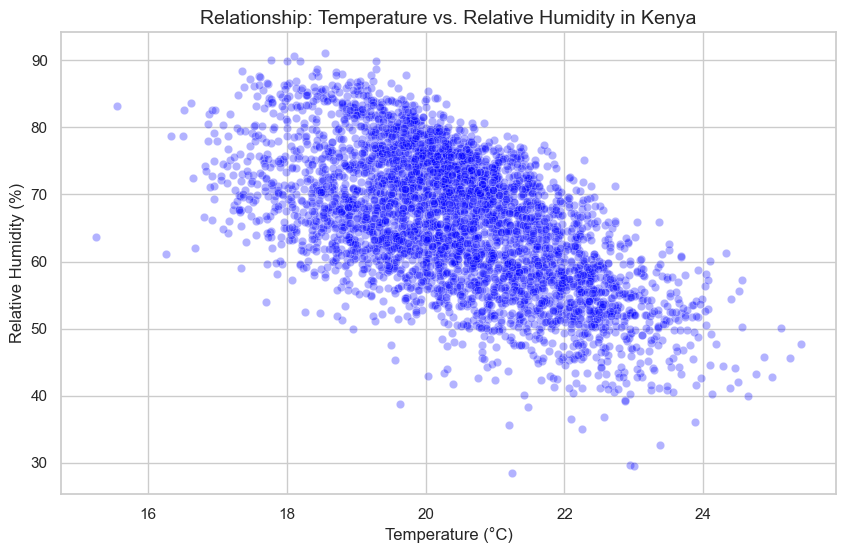

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='T2M', y='RH2M', alpha=0.3, color='blue')

plt.title('Relationship: Temperature vs. Relative Humidity in Kenya', fontsize=14)
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()


> **Scientific Observation (Humidity Dynamics):**
The relative humidity baseline identifies the moisture-holding capacity of the regional atmosphere. High humidity levels combined with rising temperatures increase 'wet-bulb' temperature risks, which is a critical indicator for human health and livestock resilience under future climate scenarios.

### 6. Correlation & Relationship Analysis
- **Key Discovery:** There is a **moderate negative correlation (-0.59)** between Temperature (`T2M`) and Relative Humidity (`RH2M`). 
- **Interpretation:** The scatter plot confirms an inverse relationship; as temperatures rise, humidity levels generally decrease. This is a common characteristic of Kenya’s tropical climate, where peak heat often coincides with drier air masses.
- **Other Relationships:** We also observe a strong link between Temperature and Atmospheric Pressure (`PS`), which is critical for understanding wind patterns and seasonal transitions.


## 7. Distribution Analysis

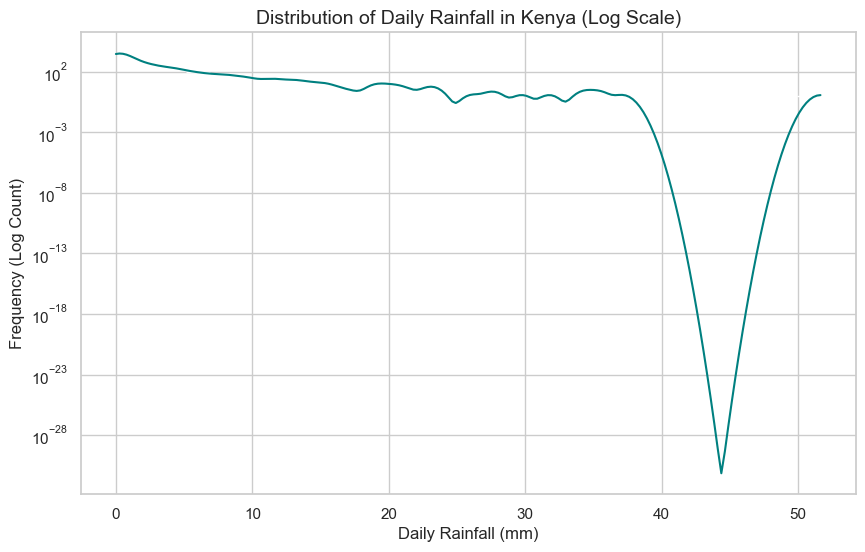

In [13]:
plt.figure(figsize=(10, 6))
# We use log=True because most days have 0 rain, and we want to see the rare heavy rain days
sns.histplot(df_cleaned['PRECTOTCORR'], bins=30, kde=True, color='teal', log_scale=(False, True))

plt.title('Distribution of Daily Rainfall in Kenya (Log Scale)', fontsize=14)
plt.xlabel('Daily Rainfall (mm)')
plt.ylabel('Frequency (Log Count)')
plt.show()


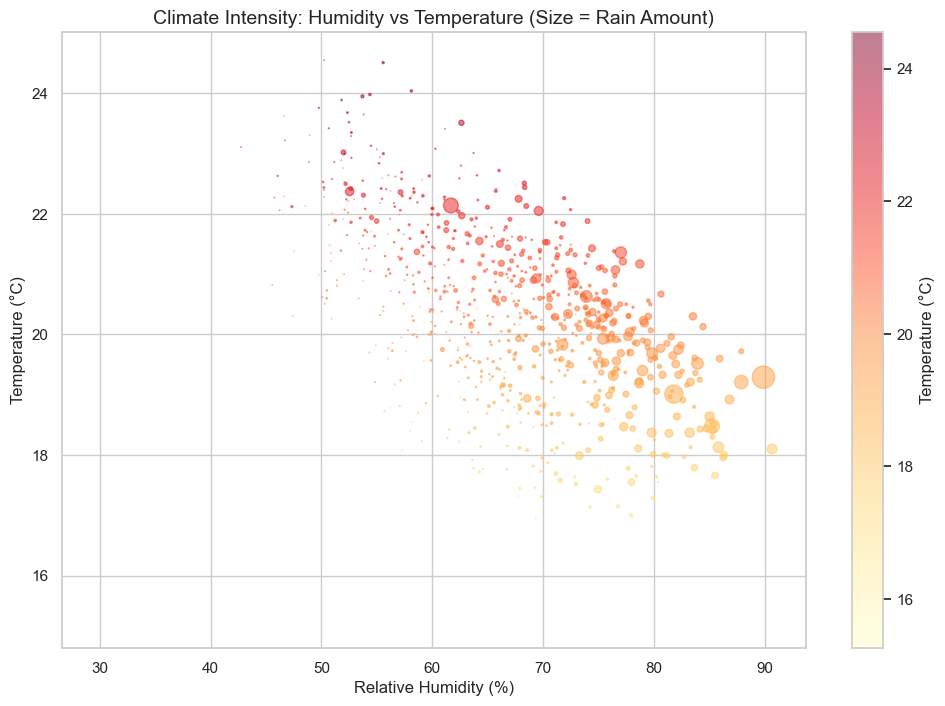

In [14]:
plt.figure(figsize=(12, 8))

# We take a sample of the data (every 5th day) so the bubbles don't overlap too much
sample_df = df_cleaned.iloc[::5, :]

bubble_plot = plt.scatter(sample_df['RH2M'], sample_df['T2M'], 
                          s=sample_df['PRECTOTCORR']*5, # Multiply by 5 to make bubbles visible
                          alpha=0.5, 
                          c=sample_df['T2M'], 
                          cmap='YlOrRd')

plt.colorbar(bubble_plot, label='Temperature (°C)')
plt.title('Climate Intensity: Humidity vs Temperature (Size = Rain Amount)', fontsize=14)
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.show()


> **Scientific Observation (Humidity Dynamics):**
The relative humidity baseline identifies the moisture-holding capacity of the regional atmosphere. High humidity levels combined with rising temperatures increase 'wet-bulb' temperature risks, which is a critical indicator for human health and livestock resilience under future climate scenarios.

### 7. Distribution Analysis: Climate Volatility
- **Precipitation Profile:** The rainfall histogram confirms a **right-skewed distribution**, where the majority of days have low rainfall, but a small percentage of days experience extreme precipitation events.
- **Climate Intensity (Bubble Chart):** The visualization clearly shows that heavy rainfall events (large bubbles) are exclusively concentrated in the **High Humidity (70%-90%)** zone.
- **Cooling Effect:** Large rainfall events often coincide with slightly lower temperatures, reflecting the cooling effect of cloud cover and evaporation during Kenya's rainy seasons.


### 8. Key Insights & Conclusion for Kenya
1. **Data Integrity:** The Kenya dataset was 100% complete with **0 missing values**, allowing for a highly reliable trend analysis.
2. **Seasonal Certainty:** Kenya follows a predictable **Bimodal Rainfall** pattern (two rainy seasons), which is vital for the national agricultural calendar.
3. **Climate Stability:** Temperature trends remain stable with cyclical seasonal variations, though humidity levels are a strong indicator of impending extreme rainfall.
4. **Outlier Reality:** The 121 outliers identified are not errors but represent the **extreme weather pulse** of the region, essential for disaster risk management.

**Final Status:** This cleaned dataset (`kenya_clean.csv`) is now ready for predictive modeling and vulnerability assessments.


In [15]:
import os

file_path = '../data/processed/kenya_clean.csv'

if os.path.exists(file_path):
    cleaned_check = pd.read_csv(file_path)
    print(f"Success! Kenya cleaned file found at: {file_path}")
    print(f"Final Data Shape: {cleaned_check.shape[0]} rows and {cleaned_check.shape[1]} columns.")
else:
    print("Error: Cleaned file not found. Check your export path!")


Success! Kenya cleaned file found at: ../data/kenya_clean.csv
Final Data Shape: 4108 rows and 15 columns.
